# Creating data frames for looking at the IL17 gene locus

## RNAseq data frame for IL17 gene expression

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [ ]:
RNA_seq = pd.read_csv('data/mmc2.csv')
RNA_seq.head()

In [ ]:
RNA_seq_IL17 = RNA_seq[
    (RNA_seq["Unnamed: 0"] == "Il17a") | 
    (RNA_seq["Unnamed: 0"] == "Il17b") |
    (RNA_seq["Unnamed: 0"] == "Il17c") |
    (RNA_seq["Unnamed: 0"] == "Il17d") |
    (RNA_seq["Unnamed: 0"] == "Il17f")
    ]
RNA_seq_IL17
mean_IL17_exp = RNA_seq_IL17.iloc[:, 1:].mean()
top10_IL17_exp = mean_IL17_exp.nlargest(10)
print(top10_IL17_exp)



In [ ]:
RNA_seq_IL17.to_csv('data/RNA_seq_IL17.csv', index=False, header=True)
RNA_seq_IL17_check = pd.read_csv('data/RNA_seq_IL17.csv')
RNA_seq_IL17_check

In [ ]:
Tgd_cells = ["Unnamed: 0" ,
            "MPP4.135+.BM" ,
            "preT.DN1.Th" ,
            "preT.DN2a.Th" ,
            "preT.DN2b.Th" ,
            "preT.DN3.Th" ,
            "T.DN4.Th" ,
            "Tgd.g1.1+d1.24a+.Th" ,
            "Tgd.g2+d1.24a+.Th" ,
            "Tgd.g2+d17.24a+.Th" ,
            "Tgd.Sp" ,
            "Tgd.g1.1+d1.LN" ,
            "Tgd.g2+d1.LN" ,
            "Tgd.g2+d17.LN"
            ]


RNA_seq_gd_IL17 = RNA_seq_IL17[Tgd_cells].copy()
RNA_seq_gd_IL17.describe()

## ATAC data frame with summits 100kb from IL17 locus

In [ ]:
ATAC_seq = pd.read_csv('data/ATAC_pfiltered.csv')
ATAC_seq.head()

In [ ]:
ATAC_seq_IL17 = ATAC_seq[ATAC_seq['genes.within.100Kb'].str.contains('Il17a|Il17b|Il17c|Il17d|Il17f', case=False, na=False)].copy()
ATAC_seq_IL17

In [ ]:
ATAC_seq_IL17.to_csv('data/ATAC_seq_IL17.csv', index=False, header=True)
ATAC_seq_IL17_check = pd.read_csv('data/ATAC_seq_IL17.csv')
ATAC_seq_IL17_check

In [ ]:
ATAC_seq_gd_IL17 = pd.concat([ATAC_seq_IL17[[
        "ImmGenATAC1219.peakID",
        "chrom",
        "Summit",
        "mm10.60way.phastCons_scores",
        "_-log10_bestPvalue",
        "Included.in.systematic.analysis",
        "TSS", 
        "genes.within.100Kb"
    ]],
    ATAC_seq_IL17[Tgd_cells[1:]].copy()], axis=1)
ATAC_seq_gd_IL17

# Looking at the IL17 locus in different cell types 

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [ ]:
Tgd_cells = ["Unnamed: 0" ,
            "MPP4.135+.BM" ,
            "preT.DN1.Th" ,
            "preT.DN2a.Th" ,
            "preT.DN2b.Th" ,
            "preT.DN3.Th" ,
            "T.DN4.Th" ,
            "Tgd.g1.1+d1.24a+.Th" ,
            "Tgd.g2+d1.24a+.Th" ,
            "Tgd.g2+d17.24a+.Th" ,
            "Tgd.Sp" ,
            "Tgd.g1.1+d1.LN" ,
            "Tgd.g2+d1.LN" ,
            "Tgd.g2+d17.LN"
            ]

RNA_seq = pd.read_csv('data/mmc2.csv')

RNA_seq_gd = RNA_seq[Tgd_cells[1:]].copy()

RNA_seq_val = RNA_seq.drop(columns="Unnamed: 0").copy()
RNA_seq_val.index = RNA_seq["Unnamed: 0"]

## loading the IL17 data sets

In [ ]:
RNA_seq_IL17 = pd.read_csv('data/RNA_seq_IL17.csv')

RNA_seq_IL17_val = RNA_seq_IL17.drop(columns="Unnamed: 0").copy()
RNA_seq_IL17_val.index = RNA_seq_IL17["Unnamed: 0"]

RNA_seq_IL17_val


,LTHSC.34-.BM,LTHSC.34+.BM,STHSC.150-.BM,MPP4.135+.BM,proB.CLP.BM,proB.FrA.BM,proB.FrBC.BM,B.FrE.BM,B1b.PC,B.T1.Sp,...,MF.PC,MF.Fem.PC,DC.4+.Sp,DC.8+.Sp,DC.pDC.Sp,FRC.SLN,IAP.SLN,BEC.SLN,LEC.SLN,Ep.MEChi.Th
Unnamed: 0,,,,,,,,,,,,,,,,,,,,,
Il17a,1.020795,1.02126,1.021750,1.021812,1.023171,1.140409,1.024462,1.025833,1.025543,1.024819,...,1.025785,1.025785,1.021812,1.022767,1.024462,1.019656,1.017884,1.019107,1.017884,1.005329
Il17b,1.020795,1.02126,1.021750,1.021812,1.023171,1.021346,1.024462,1.025833,1.025543,1.024819,...,1.025785,1.025785,1.126600,1.022767,1.024462,1.019656,1.017884,1.040295,1.017884,1.052731
Il17c,1.020795,1.02126,1.021750,1.021812,1.368419,1.021346,1.024462,3.296594,1.516769,3.383058,...,1.025785,1.634780,1.146294,1.147249,1.685787,1.019656,1.017884,1.443479,1.017884,1.041095
Il17f,1.096732,1.02126,1.206849,1.136401,1.023171,1.415983,2.791838,1.025833,2.134394,1.024819,...,1.025785,1.025785,1.021812,1.147249,1.392594,1.135090,1.017884,1.040295,1.017884,1.021351


table to compare IL17 expression in different cell types

In [ ]:
cells_to_compare = ["Tgd.g2+d17.LN", "Tgd.g2+d1.LN", "ILC3.CCR6+.SI", "NKT.Sp.LPS.3hr", "T.4.Th"]

IL17_expression_comparison = RNA_seq_IL17_val[cells_to_compare].copy()
IL17_expression_comparison.to_csv('data/IL17_expression_comparison_for_poster.csv', index=True, header=True)
IL17_expression_comparison

,Tgd.g2+d17.LN,Tgd.g2+d1.LN,ILC3.CCR6+.SI,NKT.Sp.LPS.3hr,T.4.Th
Unnamed: 0,,,,,
Il17a,1.023995,1.024819,104.836685,34.636492,1.024462
Il17b,1.023995,1.024819,1.023171,1.025833,1.024462
Il17c,1.023995,1.426854,1.023171,1.025833,1.024462
Il17f,40.083782,3.957685,267.749944,24.580994,1.024462


In [ ]:
ATAC_seq_IL17 = pd.read_csv('data/ATAC_seq_IL17.csv')

### were is IL17 expressed?

In [ ]:
mean_IL17_expr = RNA_seq_IL17_val.to_numpy().mean()
std_IL17_expr = RNA_seq_IL17_val.to_numpy().std()

IL17_expr_cells_RNA = RNA_seq_IL17_val[RNA_seq_IL17_val.columns[RNA_seq_IL17_val.max(axis=0) > 10]].copy()
IL17_expr_cells_RNA
                

,T.4.Sp.aCD3+CD40.18hr,Treg.4.FP3+.Nrplo.Co,NKT.Sp.LPS.3hr,Tgd.g2+d17.LN,ILC3.NKp46-CCR6-.SI,ILC3.CCR6+.SI
Unnamed: 0,,,,,,
Il17a,1.025785,23.987840,34.636492,1.023995,42.175516,104.836685
Il17b,1.025785,1.024859,1.025833,1.023995,1.022363,1.023171
Il17c,1.565833,1.206231,1.025833,1.023995,1.271327,1.023171
Il17f,10.462818,1.024859,24.580994,40.083782,75.919477,267.749944


In [ ]:
IL17_expr_cells_ATAC = ATAC_seq_IL17[RNA_seq_IL17_val.columns[RNA_seq_IL17_val.max(axis=0) > 10]].copy()
IL17_expr_cells_ATAC[ATAC_seq_IL17.columns[0:8]] = ATAC_seq_IL17[ATAC_seq_IL17.columns[0:8]]
IL17_expr_cells_ATAC["Tgd.g2+d1.LN"] = ATAC_seq_IL17["Tgd.g2+d1.LN"] #as a reference

## IL17f

### plotting OCRs near the IL17f gene locus

In [ ]:
gene_annotations = pd.read_csv('data/gene_annotations.csv')
IL17_genes = gene_annotations[gene_annotations['gene_name'].str.contains('Il17a|Il17b|Il17c|Il17d|Il17f', case=False, na=False)].copy()
IL17_genes

,gene_name,transcript_name,chrom,strand,txStart,txEnd,cdsStart,cdsEnd,exonCount,exonStarts,exonEnds
2079,Il17a,NM_010552,chr1,+,20730904,20734496,20730961,20733859,3,"20730904,20732095,20733621,","20730988,20732307,20734496,"
4195,Il17b,NM_019508,chr18,+,61687934,61692537,61687983,61692437,3,"61687934,61690117,61692205,","61688004,61690407,61692537,"
8932,Il17f,NM_145856,chr1,-,20777145,20784270,20777766,20784199,3,"20777145,20779290,20784172,","20778004,20779511,20784270,"
34980,Il17c,NM_145834,chr8,+,122422019,122423639,122422118,122423568,2,"122422019,122423306,","122422405,122423639,"
36895,Il17d,NM_145837,chr14,+,57524828,57543166,57524906,57542640,3,"57524828,57525303,57542333,","57524921,57525599,57543166,"


In [ ]:
IL17f_start = IL17_genes.loc[8932, "txEnd"]
IL17f_end = IL17_genes.loc[8932, "txStart"]

In [ ]:
ATAC_seq_IL17f = IL17_expr_cells_ATAC[IL17_expr_cells_ATAC['genes.within.100Kb'].str.contains('Il17f', case=False, na=False)].copy()
ATAC_seq_IL17f

,T.4.Sp.aCD3+CD40.18hr,Treg.4.FP3+.Nrplo.Co,NKT.Sp.LPS.3hr,Tgd.g2+d17.LN,ILC3.NKp46-CCR6-.SI,ILC3.CCR6+.SI,ImmGenATAC1219.peakID,chrom,Summit,mm10.60way.phastCons_scores,_-log10_bestPvalue,Included.in.systematic.analysis,TSS,genes.within.100Kb,Tgd.g2+d1.LN
1,2.14,1.89,5.04,56.70,26.18,32.45,ImmGenATAC1219.peak_2075,chr1,20686124,0.22,9.93,1.0,NaN,"Pkhd1,Linc-md1,Mir206,Mir133b,Il17a,Il17f",4.17
2,2.76,2.73,2.87,4.15,2.09,6.65,ImmGenATAC1219.peak_2077,chr1,20700177,0.19,2.07,1.0,NaN,"Pkhd1,Linc-md1,Mir206,Mir133b,Il17a,Il17f",1.95
3,1.12,1.89,1.09,2.60,0.57,0.15,ImmGenATAC1219.peak_2078,chr1,20701584,0.04,1.49,NaN,NaN,"Pkhd1,Linc-md1,Mir206,Mir133b,Il17a,Il17f",0.68
4,1.16,2.11,4.08,26.14,19.37,17.47,ImmGenATAC1219.peak_2081,chr1,20725819,0.64,4.64,1.0,NaN,"Linc-md1,Mir206,Mir133b,Il17a,Il17f,Mcm3",1.91
5,2.76,3.01,2.12,13.28,11.12,16.75,ImmGenATAC1219.peak_2083,chr1,20738699,0.19,3.41,1.0,NaN,"Linc-md1,Mir206,Mir133b,Il17a,Il17f,Mcm3",1.95
6,8.52,7.02,4.96,25.00,35.01,42.39,ImmGenATAC1219.peak_2084,chr1,20740472,0.00,13.64,1.0,NaN,"Linc-md1,Mir206,Mir133b,Il17a,Il17f,Mcm3",6.71
7,12.49,9.83,8.79,71.34,67.30,58.74,ImmGenATAC1219.peak_2085,chr1,20740740,0.34,24.17,1.0,NaN,"Linc-md1,Mir206,Mir133b,Il17a,Il17f,Mcm3",18.62
8,2.02,17.36,0.95,69.89,2.65,0.15,ImmGenATAC1219.peak_2086,chr1,20744070,0.00,7.53,1.0,NaN,"Linc-md1,Mir206,Mir133b,Il17a,Il17f,Mcm3",5.03
9,0.38,1.99,1.14,0.13,0.95,1.41,ImmGenATAC1219.peak_2087,chr1,20748728,0.45,2.59,1.0,NaN,"Linc-md1,Mir206,Mir133b,Il17a,Il17f,Mcm3",0.12
10,2.29,6.33,11.87,44.26,32.10,28.01,ImmGenATAC1219.peak_2089,chr1,20754593,0.29,8.58,1.0,NaN,"Linc-md1,Mir206,Mir133b,Il17a,Il17f,Mcm3",1.95


In [ ]:
IL17f_data = ATAC_seq_IL17f.iloc[:, 0:6].copy()
IL17f_data["Summit"] = ATAC_seq_IL17f["Summit"]
IL17f_data.insert(0, "Tgd.g2+d1.LN", ATAC_seq_IL17f["Tgd.g2+d1.LN"])
IL17f_data

,Tgd.g2+d1.LN,T.4.Sp.aCD3+CD40.18hr,Treg.4.FP3+.Nrplo.Co,NKT.Sp.LPS.3hr,Tgd.g2+d17.LN,ILC3.NKp46-CCR6-.SI,ILC3.CCR6+.SI,Summit
1,4.17,2.14,1.89,5.04,56.70,26.18,32.45,20686124
2,1.95,2.76,2.73,2.87,4.15,2.09,6.65,20700177
3,0.68,1.12,1.89,1.09,2.60,0.57,0.15,20701584
4,1.91,1.16,2.11,4.08,26.14,19.37,17.47,20725819
5,1.95,2.76,3.01,2.12,13.28,11.12,16.75,20738699
6,6.71,8.52,7.02,4.96,25.00,35.01,42.39,20740472
7,18.62,12.49,9.83,8.79,71.34,67.30,58.74,20740740
8,5.03,2.02,17.36,0.95,69.89,2.65,0.15,20744070
9,0.12,0.38,1.99,1.14,0.13,0.95,1.41,20748728
10,1.95,2.29,6.33,11.87,44.26,32.10,28.01,20754593


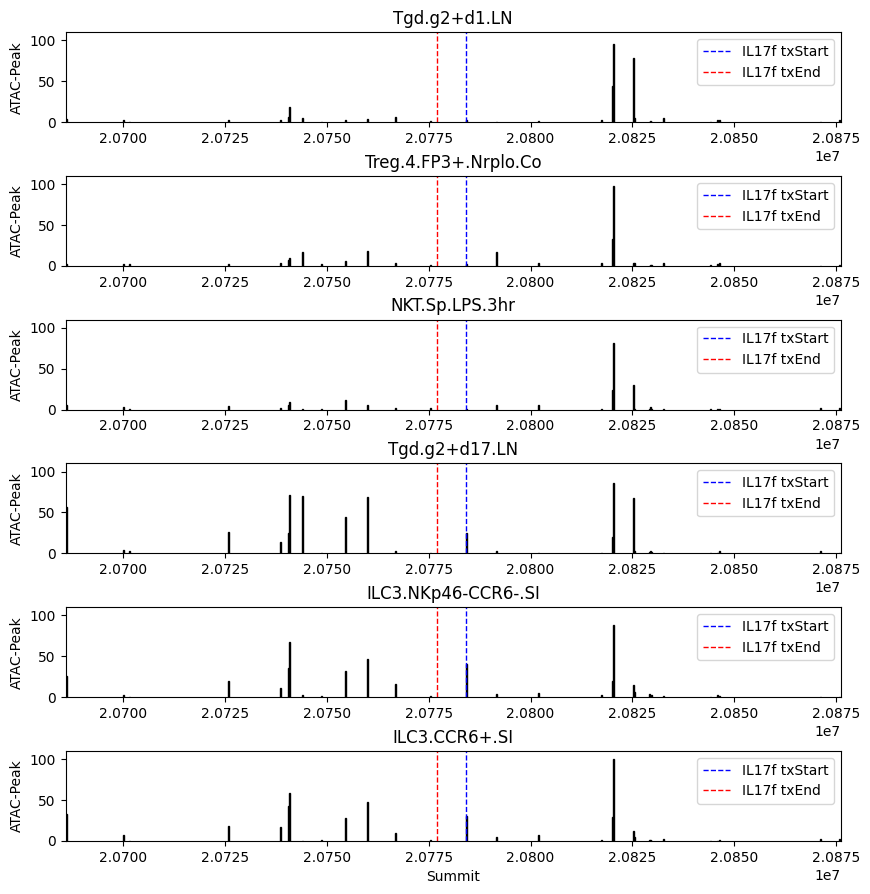

In [ ]:
summits = "Summit"
cell_types = ["Tgd.g2+d1.LN",
            "Treg.4.FP3+.Nrplo.Co",
            "NKT.Sp.LPS.3hr",
            "Tgd.g2+d17.LN",
            "ILC3.NKp46-CCR6-.SI",
            "ILC3.CCR6+.SI",
]


fig, axs = plt.subplots(6, 1, figsize=(10, 10.5), sharex=False, gridspec_kw={"hspace": 0.6})


IL17f_data = IL17f_data.sort_values(summits)

x = IL17f_data[summits].to_list()


for ax, cell_type, t in zip(axs, cell_types, cell_types):
    y = IL17f_data[cell_type].to_list()

    ax.bar(x, y, width=250, color="black", edgecolor="black")
    ax.set_title(t)
    ax.set_ylabel("ATAC-Peak")
    ax.axvline(IL17f_start, color='blue', linestyle='--', linewidth=1, label='IL17f txStart')
    ax.axvline(IL17f_end, color='red', linestyle='--', linewidth=1, label='IL17f txEnd')
    ax.legend()
    ax.set_ylim(0, 110)
    ax.set_xlim(min(x) - 250, max(x) + 250)

axs[-1].set_xlabel("Summit")

plt.savefig('tilmann_plots/ATAC-peaks around the IL17f gene locus', dpi=300)
plt.savefig('plots_for_poster/ATAC-peaks around the IL17f gene locus', dpi=300)
plt.show()


- the clearest difference between those cell types, which express IL17f and those, which do not, is the OCR at the TSS
- one OCR upstream is active everywhere
- another OCR upstream is especially active in both Tgd cell types
- in IL17f expressing cells there seem to be more active OCRs downstream from the gene
- the OCR-pattern of NK.Sp.LPS.3hr looks similar to those cells not expressing IL17f, even though they do express some IL17f (expression value: 25)
- peak at 2744000 is unique to Tgd.g2+d17.LN

Data from UCSC Genome Browser on Mouse as a comparison

![image.png](attachment:image.png)

some potential transcription factor for the unique peak from JASPAR (UCSC Genome Browser on Mouse)
- some of these transcription factors are also expressed in IL17 producing Tgd cells

![image-2.png](attachment:image-2.png)

![image.png](attachment:image.png)

### see if threre are any cells with the unique peak or a peak at the TSS, that do not express IL17f

In [ ]:
IL17f_expr = RNA_seq_val[RNA_seq_val.index == "Il17f"].copy()
IL17f_expr

,LTHSC.34-.BM,LTHSC.34+.BM,STHSC.150-.BM,MPP4.135+.BM,proB.CLP.BM,proB.FrA.BM,proB.FrBC.BM,B.FrE.BM,B1b.PC,B.T1.Sp,...,MF.PC,MF.Fem.PC,DC.4+.Sp,DC.8+.Sp,DC.pDC.Sp,FRC.SLN,IAP.SLN,BEC.SLN,LEC.SLN,Ep.MEChi.Th
Unnamed: 0,,,,,,,,,,,,,,,,,,,,,
Il17f,1.096732,1.02126,1.206849,1.136401,1.023171,1.415983,2.791838,1.025833,2.134394,1.024819,...,1.025785,1.025785,1.021812,1.147249,1.392594,1.13509,1.017884,1.040295,1.017884,1.021351


In [ ]:
IL17f_TSS_ATAC = ATAC_seq_IL17[ATAC_seq_IL17["Summit"] == 20784347].copy()
IL17f_TSS_ATAC

,ImmGenATAC1219.peakID,chrom,Summit,mm10.60way.phastCons_scores,_-log10_bestPvalue,Included.in.systematic.analysis,TSS,genes.within.100Kb,LTHSC.34-.BM,LTHSC.34+.BM,...,DC.4+.Sp,DC.8+.Sp,DC.pDC.Sp,DC.103+11b+.SI,DC.103+11b-.SI,FRC.SLN,IAP.SLN,BEC.SLN,LEC.SLN,Ep.MEChi.Th
14,ImmGenATAC1219.peak_2095,chr1,20784347,0.55,11.49,1.0,Il17f,"Il17a,Il17f,Mcm3",0.41,0.71,...,2.1,1.81,1.14,0.11,1.82,1.94,0.1,1.92,3.39,0.94


In [ ]:
IL17f_unique_peak_ATAC = ATAC_seq_IL17[ATAC_seq_IL17["Summit"] == 20744070].copy()
IL17f_unique_peak_ATAC

,ImmGenATAC1219.peakID,chrom,Summit,mm10.60way.phastCons_scores,_-log10_bestPvalue,Included.in.systematic.analysis,TSS,genes.within.100Kb,LTHSC.34-.BM,LTHSC.34+.BM,...,DC.4+.Sp,DC.8+.Sp,DC.pDC.Sp,DC.103+11b+.SI,DC.103+11b-.SI,FRC.SLN,IAP.SLN,BEC.SLN,LEC.SLN,Ep.MEChi.Th
8,ImmGenATAC1219.peak_2086,chr1,20744070,0.0,7.53,1.0,NaN,"Linc-md1,Mir206,Mir133b,Il17a,Il17f,Mcm3",0.41,0.1,...,0.44,0.36,0.11,0.53,0.11,0.56,1.26,0.11,1.04,1.26


test the unique peaks value against to other cell types

In [ ]:
import scipy.stats as stats

unique_peak_others = IL17f_unique_peak_ATAC[IL17f_unique_peak_ATAC.columns[8:]].copy()
unique_peak_others = unique_peak_others.drop("Tgd.g2+d17.LN", axis=1)

unique_peak_others = unique_peak_others.melt()["value"].to_list()

In [ ]:
t_stat, p_value = stats.ttest_1samp(unique_peak_others, popmean=IL17f_unique_peak_ATAC["Tgd.g2+d17.LN"])
print("t-statistic:", t_stat)
print("p-value:", p_value)

t-statistic: -279.929504000158
p-value: 1.3310975317788773e-131


- the expression of IL17f seems to be quite promotor driven, because the OCR at the TSS is only active in cell types expressing IL17f (probably not regulated by silencers)
- the peak we found in IL17f expressing Tgd cells is very unique for them and is only slightly active in Treg cells (not producing IL17f), but not in any others
    - the peak value is significantly different from the other ATACseq values at that summit (very low p-value) 

### test if difference in OCRs is significant between Tgd.g2+d17.LN and Tgd.g2+d1.LN aswell as ILC3.NKp46-CCR6-.SI

In [ ]:
from scipy.stats import wilcoxon
from scipy.stats import ttest_rel

In [ ]:
stat, p = wilcoxon(IL17f_data["Tgd.g2+d17.LN"], IL17f_data["Tgd.g2+d1.LN"])
print(str("stat = ") + str(stat))
print(str("p = ") + str(p))

stat = 161.0
p = 0.1459994912147522


In [ ]:
stat, p = wilcoxon(IL17f_data["Tgd.g2+d17.LN"], IL17f_data["ILC3.NKp46-CCR6-.SI"])
print(str("stat = ") + str(stat))
print(str("p = ") + str(p))

stat = 204.0
p = 0.5698575973510742


In [ ]:
stat, p = ttest_rel(IL17f_data["Tgd.g2+d17.LN"], IL17f_data["Tgd.g2+d1.LN"])
print(str("stat = ") + str(stat))
print(str("p = ") + str(p))

stat = 2.4046840016438136
p = 0.022795711214076995


In [ ]:
stat, p = ttest_rel(IL17f_data["Tgd.g2+d17.LN"], IL17f_data["ILC3.NKp46-CCR6-.SI"])
print(str("stat = ") + str(stat))
print(str("p = ") + str(p))

stat = 1.5552372352372033
p = 0.1307365282851432
